In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.simulation import Simulation
from src.config import Config
from src.builders import build_problem
from src.noise import add_noise_snr
from src.layers import create_layers_from_interfaces
from src.plot.plot_tools import set_plot_style
from sampling.parametrization import ModelParameterization
from sampling.posterior import FWIPosterior
from sampling_toolbox.svgd import SVGD
from sampling_toolbox.utilities.kl_tracker import GenericKLTracker
from sampling_toolbox.gauss_vi import GaussianODE
from sampling_toolbox.examples.plotting import plot_result_gmm

import time
set_plot_style()

In [2]:
config = Config(n_receivers=8, x_min=600., x_max=2000.,
                   z_rec=50., z_src=20., x_src=50., nq_prop=256, f0=10., nq_evan=256, kx_max_factor=6,
                   total_time=2.0, delay=0.2, epsilon=1.25, free_surface=False, nfft_pad_factor=1, source_deriv=True)
param, acq = build_problem(config)
dxr = acq.xr[1] - acq.xr[0]
dt = param.dt
seed = 42
rng = np.random.default_rng(seed)

vps = np.array([1500.0, 2700.0, 3200.0]) # 1800, 3200, or 2200, 3000
vp_ref = np.array([vps[1], vps[2]])
z_int = np.array([0.0, 100., 250., 400.])
rhos = np.array([2000.0, 2000.0, 2000.0])
layers = create_layers_from_interfaces(z_int, vps, rhos)

sim = Simulation(config)
d_obs = sim.forward(layers)
d_obs_noise, std_noise = add_noise_snr(d_obs, snr_db=10, seed=seed)

In [3]:
mu = 2500.0 * np.ones(len(vp_ref))
sigma = 600.0 * np.ones(len(mu))
cov = np.diag(sigma**2)
beta = sim.param.dt / config.total_time
print(f"Tempering factor beta: {beta:.4f}")

param = ModelParameterization(
    layers,
    invert_vp=True,
    invert_h=False,
    startv=1,
    prior_mode='gaussian',
    mu=mu,
    cov=cov
)
param.vp_bounds = (800., 4500.)

bayes = FWIPosterior(
    dobs=d_obs_noise,
    parametrization=param,
    sim=sim,
    prior_mu=mu,
    prior_cov=cov,
    std_noise=float(std_noise),
    beta=beta,
)

Tempering factor beta: 0.0031


In [4]:
vp_min, vp_max, npts = 800, 4500, 30
vp_min2, vp_max2 = 800, 4500

x_vals = np.linspace(vp_min, vp_max, npts)
y_vals = np.linspace(vp_min2, vp_max2, npts)
xgrid, ygrid = np.meshgrid(x_vals, y_vals, indexing='xy')
logPOST = np.empty_like(xgrid)
GRAD1 = np.empty_like(xgrid)
GRAD2 = np.empty_like(ygrid)
start_time = time.time()
for i in range(npts):
    for j in range(npts):
        point = np.array([xgrid[i, j], ygrid[i, j]])
        logPOST[i,j], GRAD  = bayes.log_and_grad_post(np.array([point[0], point[1]]))
        GRAD1[i,j], GRAD2[i,j] = GRAD[0], GRAD[1]
elapsed_time = time.time() - start_time
print(f"generated misfit map in {elapsed_time:.3f} seconds.")
print(f"time per forward is {elapsed_time/(npts*npts):.3f} seconds.")

generated misfit map in 192.983 seconds.
time per forward is 0.214 seconds.


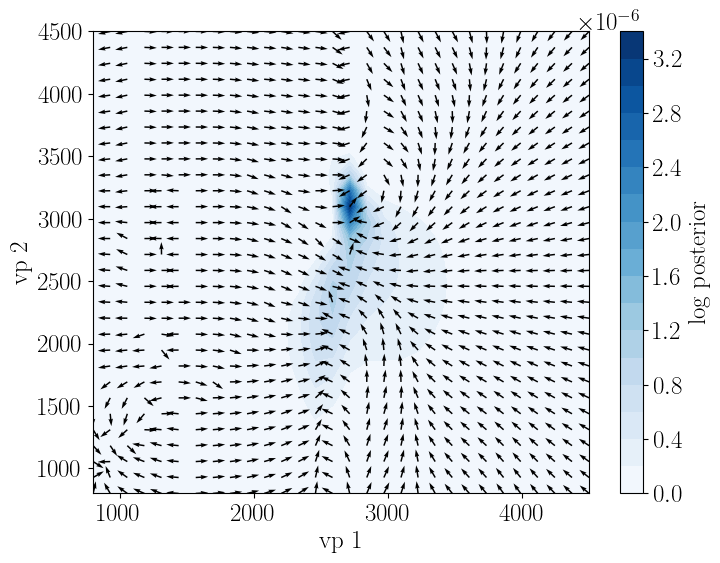

In [5]:
dv = x_vals[1] - x_vals[0]
cell_area = dv * dv
max_logpost = np.max(logPOST)
scaled_post = np.exp(logPOST - max_logpost)
POST = scaled_post / (np.sum(scaled_post) * cell_area)
# Normalize gradient
grad_norm = np.sqrt(GRAD1**2 + GRAD2**2)

# avoid division by zero
GRAD1_norm = GRAD1 / (grad_norm + 1e-12)
GRAD2_norm = GRAD2 / (grad_norm + 1e-12)

fig, ax = plt.subplots(figsize=(8, 6))

# contour plot
cf = ax.contourf(
    xgrid,
    ygrid,
    POST,
    levels=20,
    cmap="Blues"
)

# colorbar
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("log posterior")

# gradient direction arrows
ax.quiver(
    xgrid,
    ygrid,
    GRAD1_norm,
    GRAD2_norm,
    color="black",
    scale=40,      # controls arrow size
    width=0.003
)

'''traj = np.array([m[0] for m in means_id])
x_traj = traj[:, 0]
y_traj = traj[:, 1]

# Plot trajectory in red
ax.plot(
    x_traj,
    y_traj,
    color="red",
    marker="o",
    markersize=2,
    linewidth=2,
    label="trajectory"
)

theta = np.linspace(0, 2*np.pi, 200)

for mean, R in zip(traj, Rs_id):

    # flatten mean to shape (2,)
    mean = np.asarray(mean).flatten()

    # remove extra list nesting in Rs_id
    R = np.asarray(R[0])

    # unit circle
    circle = np.vstack([
        np.cos(theta),
        np.sin(theta)
    ])

    # transform circle using Cholesky factor
    ellipse = mean[:, None] + R @ circle

    ax.plot(
        ellipse[0],
        ellipse[1],
        color="red",
        alpha=0.15,
        linewidth=1.5
    )'''

ax.set_xlabel("vp 1")
ax.set_ylabel("vp 2")

plt.show()

In [6]:
# monitor KL divergence
max_logPOST = np.max(logPOST)
dx = x_vals[1] - x_vals[0]
dy = x_vals[1] - x_vals[0]
# 3. Compute log(Z) stably
log_Z = max_logPOST + np.log(np.sum(np.exp(logPOST - max_logPOST))) + np.log(dx) + np.log(dy)
print(log_Z)

7.612222182908093


In [7]:
dt = 0.001
nit = 200
n_comp = 3
sigma = 200.
mu = [np.array([1900., 1900.]), np.array([3700., 2200.]), np.array([2300., 3700.])] 
sigma = [np.diag([sigma**2, sigma**2]), np.diag([sigma**2, sigma**2]), np.diag([sigma**2, sigma**2])]
mu_in = [m.copy() for m in mu]
R = [np.linalg.cholesky(sigma[i]) for i in range(n_comp)]
R_in  = [r.copy() for r in R]
dtw = 0.1

print(np.array(mu[0]).squeeze())
print(bayes.log_and_grad_post(np.array(mu[0]).squeeze()))
print(bayes.log_likelihood(np.array(mu[0]).squeeze()))
print(bayes.grad_log_likelihood(np.array(mu[0]).squeeze()))
print(bayes.log_prior(np.array(mu[0]).squeeze()))
print(bayes.grad_log_prior(np.array(mu[0]).squeeze()))

integrator = 'heun_adaptive'
gvi_id = GaussianODE(bayes.log_and_grad_post, step_size=dt, n_iter=nit, time_scheme=integrator, precond='natural', step_size_w=dtw, time_scheme_fr=integrator)
gvi_id.kl_track = GenericKLTracker(log_Z)

final_mean_id, final_R_id, final_ws_id, means_id, Rs_id, ws_id, kl_hist_id = gvi_id.sample([m.copy() for m in mu_in], [r.copy() for r in R])

[1900. 1900.]
(np.float64(-13.97025986065886), array([0.04263426, 0.00549656]))
1.6614765161827763
[0.04096759 0.0038299 ]
-15.631736376841637
[0.00166667 0.00166667]
--- [ACCEPTED] Global NRMSE: 0.1397 | Next dt: 0.001500 ---
FR step =  1.7573977755444825e-05
Iter   1 | dt: 0.0010 | KL: 11.3210
------------
weights [0.333287   0.33338802 0.33332498]
mean 0 [1904.81404279 1899.48438031]
std 0 [195.23613128 199.83149469]
mean 1 [3699.85657949 2200.03592279]
std 1 [200.17521868 200.17700316]
mean 2 [2301.3135898  3699.79027076]
std 2 [200.06377797 200.21676219]
--- [ACCEPTED] Global NRMSE: 0.1450 | Next dt: 0.002250 ---
FR step =  3.7462709670291053e-05
Iter   2 | dt: 0.0015 | KL: 10.9037
------------
weights [0.33319804 0.33349943 0.33330253]
mean 0 [1911.18282114 1898.68482785]
std 0 [189.07046005 199.61139363]
mean 1 [3699.64103091 2200.08981693]
std 1 [200.43823339 200.44259682]
mean 2 [2303.28044415 3699.48588653]
std 2 [200.13585404 200.53371801]
--- [ACCEPTED] Global NRMSE: 0.1351

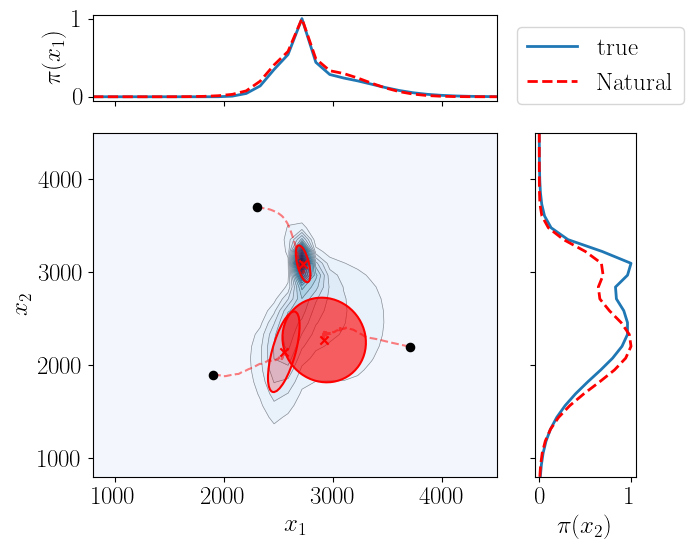

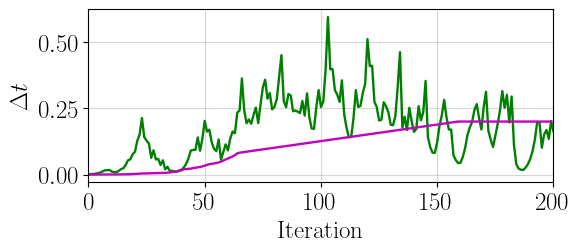

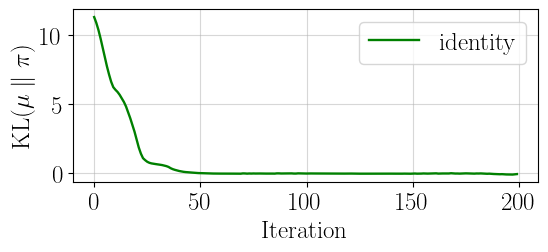

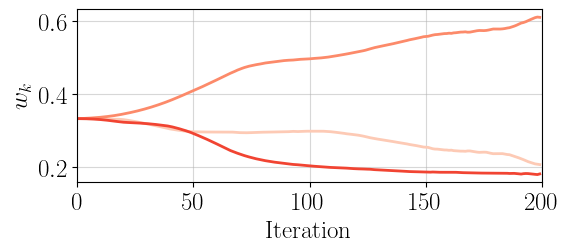

In [8]:
plot_result_gmm(xgrid, ygrid, logPOST, mus_hist=means_id, Rs=final_R_id, weights=final_ws_id, method='natural', mu0=mu_in)

plt.figure(figsize=(6, 2.25))
plt.plot(gvi_id.dt_history, color='g', label='w', lw=1.7, linestyle='-')
plt.plot(gvi_id.dt_fr_history, color='m', label='fr', lw=1.7, linestyle='-')
plt.xlabel(r'Iteration')
plt.xlim([0, 200])
plt.ylabel(r'$\Delta t$')
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 2.25))
plt.plot(kl_hist_id, color='g', label='identity', lw=1.7, linestyle='-')
plt.xlabel(r'Iteration')
plt.ylabel(r'KL$(\mu \parallel \pi)$')
#plt.yscale('log')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(6, 2.25))
weights_arr = np.array(ws_id[1:])
colors = plt.cm.Reds(np.linspace(0.2, 1, max(n_comp, 5)))
for k in range(n_comp):
    plt.plot(weights_arr[:, k], color=colors[k], lw=2, label=f"Comp {k}")
plt.xlabel(r'Iteration')
plt.ylabel(r'$w_k$')
plt.grid(True)
plt.xlim([0, nit])
plt.show()

In [ ]:
from scipy.optimize import minimize
from src.utilities import timer

def run_fwi_map(bayes, param):
    unique_map_minima = []
    num_starts = 3
    model_start = [np.array([1900., 1900.]), np.array([3700., 2200.]), np.array([2300., 3700.])]

    all_bounds = [param.vp_bounds] * param.n_vp
    for i in range(num_starts):
        # Generate a random initial guess
        random_m_init = model_start[i]
        print("Initial model :", random_m_init)
        print(f"--- Start {i+1}/{num_starts} ---")
        cost_history = []
        obj_func = make_map_objective(bayes, cost_history)
        res = minimize(
            obj_func,
            random_m_init,
            method="L-BFGS-B",
            jac=True,
            bounds=all_bounds,
            options={"maxiter": 50, "ftol": 1e-6, "gtol": 1e-4}
        )
        print(f"{'-'*50}\nInverted Vp: {res.x}")
        print(f"Completed in {len(cost_history)} evaluations.")
        
        if res.success:
            unique_map_minima.append({'vp': res.x, 'map_val': -res.fun})
            print(f"minimum found!")
        else:
            unique_map_minima.append({'vp': res.x, 'map_val': -res.fun})
            print(f"did not converged")
            
    print("\n=== All Discovered MAP Local Minima ===")
    # Sort them by objective value so the best candidate is at the top
    unique_map_minima = sorted(unique_map_minima, key=lambda x: x['map_val'])
    for idx, minimum in enumerate(unique_map_minima):
        print(f"MAP Mode #{idx}: Objective = {minimum['map_val']:.4e} | Vp = {minimum['vp'].astype(int)}")
    return 1

def make_map_objective(bayes, cost_history):
    """Define Regularized FWI objective function for MAP estimation"""
    def map_objective(model):
        with timer("log and grad eval"):
            phi_map, grad_phi_map = bayes.log_and_grad_post(model)
        l2_misfit = bayes.l2_misfit(model)
        cost_history.append(phi_map)
        m_str = "[" + ", ".join(f"{m:7.1f}" for m in model) + "]"
        print(f"Iter {len(cost_history):>2} | MAP: {phi_map:.4e} (misift: {l2_misfit:.2e} | m: {m_str}")
        # because we maximize the MAP, so minimize -MAP
        return -phi_map, -grad_phi_map 
    return map_objective

In [18]:
run_fwi_map(bayes, param)

Initial model : [1900. 1900.]
--- Start 1/3 ---
log and grad eval elapsed: 0.21 s
Iter  1 | MAP: -1.3970e+01 (misift: 4.05e+03 | m: [ 1900.0,  1900.0]
log and grad eval elapsed: 0.21 s
Iter  2 | MAP: -1.3968e+01 (misift: 4.05e+03 | m: [ 1900.0,  1900.0]
log and grad eval elapsed: 0.18 s
Iter  3 | MAP: -1.1171e+01 (misift: 3.21e+03 | m: [ 1994.9,  1901.3]
log and grad eval elapsed: 0.21 s
Iter  4 | MAP: -9.7438e+00 (misift: 2.78e+03 | m: [ 2081.7,  1899.1]
log and grad eval elapsed: 0.25 s
Iter  5 | MAP: -7.9864e+00 (misift: 2.27e+03 | m: [ 2258.6,  1900.3]
log and grad eval elapsed: 0.21 s
Iter  6 | MAP: -6.5503e+00 (misift: 1.85e+03 | m: [ 2490.6,  1913.8]
log and grad eval elapsed: 0.22 s
Iter  7 | MAP: -6.5982e+00 (misift: 1.87e+03 | m: [ 2578.8,  1933.9]
log and grad eval elapsed: 0.19 s
Iter  8 | MAP: -6.5053e+00 (misift: 1.84e+03 | m: [ 2526.6,  1922.0]
log and grad eval elapsed: 0.19 s
Iter  9 | MAP: -6.4931e+00 (misift: 1.84e+03 | m: [ 2527.9,  1930.2]
log and grad eval elapsed

1

In [9]:
svgd = SVGD(log_likelihood=bayes.log_likelihood,      
                log_prior=bayes.log_prior,
                grad_log_likelihood=bayes.grad_log_likelihood, 
                grad_log_prior=bayes.grad_log_prior,
                step_size=20., 
                n_iter=100, 
                rng=rng, 
                tol=1e-10)
print("\nRunning SVGD...")
svgd.kl_track = GenericKLTracker(log_evidence=log_Z)

seed = 42
rng = np.random.default_rng(seed)
nparticles = 100
print(bayes.mu)
initial_particles = rng.normal(loc=bayes.mu, scale=np.sqrt(np.diag(bayes.cov)), size=(nparticles, len(bayes.mu)))
svgd.print_statistics(initial_particles)

s_svgd, s_history, kl_hist = svgd.sample(initial_particles, num_samples=0)
svgd.report_calls()
svgd.print_statistics(s_svgd)
print(kl_hist)


Running SVGD...
[2500. 2500.]
+-------------+---------+-----------+
| Parameter   |    Mean |   Std Dev |
+=============+=========+===========+
| param_1     | 2491.15 |   544.74  |
+-------------+---------+-----------+
| param_2     | 2472.31 |   510.196 |
+-------------+---------+-----------+
Iteration   1 | Update Norm: 0.000593
Iteration   2 | Update Norm: 0.001406


KeyboardInterrupt: 